# MS MARCO → BEIR Formal v3

优化点：Nyström query 不再 pad 到 doc_len；BEIR eval 支持 GPU search / FAISS、embedding cache、raw text char truncate、fixed max steps。

In [ ]:
!nvidia-smi || true
import torch
print(torch.__version__, torch.cuda.is_available())

Tue Jun  2 07:54:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             13W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip -q install -U beir sentence-transformers transformers datasets accelerate tqdm faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 157.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 34.1 MB/s eta 0:00:00


In [ ]:
import pathlib
if not pathlib.Path('/content/Nystromformer/code/attention_nystrom.py').exists():
    !git clone https://github.com/mlpen/Nystromformer /content/Nystromformer
!ls /content/Nystromformer/code/attention_nystrom.py

Cloning into '/content/Nystromformer'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 297 (delta 1), reused 0 (delta 0), pack-reused 292 (from 1)
Receiving objects: 100% (297/297), 10.84 MiB | 10.66 MiB/s, done.
Resolving deltas: 100% (132/132), done.
/content/Nystromformer/code/attention_nystrom.py


In [ ]:
%%writefile /content/msmarco_beir_lsso_official_nystrom_v3.py
from __future__ import annotations
import argparse, csv, json, math, random, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from beir import util
from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval

BEIR_URL = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{}.zip"

def set_seed(seed:int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def now(): return time.strftime("%Y-%m-%d %H:%M:%S")
def ensure_dir(p): Path(p).mkdir(parents=True, exist_ok=True)
def amp_dtype(name): return None if name == "none" else (torch.bfloat16 if name == "bf16" else torch.float16)
def doc_text(doc):
    title = doc.get("title", "") or ""; text = doc.get("text", "") or ""
    return (title + " " + text).strip() if title else text

def download_dataset(name, out_dir): return util.download_and_unzip(BEIR_URL.format(name), out_dir)

def write_jsonl(path, obj):
    ensure_dir(Path(path).parent)
    with open(path, "a", encoding="utf-8") as f: f.write(json.dumps(obj, ensure_ascii=False)+"\n")

def append_csv(path, row):
    path=Path(path); ensure_dir(path.parent); exists=path.exists(); keys=list(row.keys())
    with open(path,"a",newline="",encoding="utf-8") as f:
        w=csv.DictWriter(f, fieldnames=keys)
        if not exists: w.writeheader()
        w.writerow(row)

class MSMarcoPairs(Dataset):
    def __init__(self, data_path, split="train", max_pairs=100000, seed=1):
        print(f"[{now()}] loading MS MARCO {split} from {data_path}", flush=True)
        corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split=split)
        self.corpus, self.queries = corpus, queries
        pairs=[]
        for qid, rels in qrels.items():
            if qid not in queries: continue
            for pid, score in rels.items():
                if score > 0 and pid in corpus: pairs.append((qid,pid))
        rng=random.Random(seed); rng.shuffle(pairs)
        self.pairs = pairs[:max_pairs] if max_pairs and len(pairs)>max_pairs else pairs
        print(f"[{now()}] pairs={len(self.pairs):,}", flush=True)
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        qid,pid=self.pairs[i]
        return self.queries[qid], doc_text(self.corpus[pid]), qid, pid

class PairCollator:
    def __init__(self, tok, q_len, d_len, q_chars=512, d_chars=4096):
        self.tok=tok; self.q_len=q_len; self.d_len=d_len; self.q_chars=q_chars; self.d_chars=d_chars
    def __call__(self,batch):
        qs,ds,qids,pids=zip(*batch)
        qs=[truncate_chars(x,self.q_chars) for x in qs]; ds=[truncate_chars(x,self.d_chars) for x in ds]
        q=self.tok(list(qs), padding=True, truncation=True, max_length=self.q_len, return_tensors="pt")
        d=self.tok(list(ds), padding=True, truncation=True, max_length=self.d_len, return_tensors="pt")
        return {"q_input_ids":q["input_ids"],"q_attention_mask":q["attention_mask"],"d_input_ids":d["input_ids"],"d_attention_mask":d["attention_mask"],"qids":qids,"pids":pids}

class LSSOMixer(nn.Module):
    def __init__(self, dim, heads, rank=32, gamma_max=0.3, theta_gamma_init=-4.0, eps=1e-5):
        super().__init__(); assert dim%heads==0
        self.dim=dim; self.heads=heads; self.rank=rank; self.dh=dim//heads; self.gamma_max=gamma_max; self.eps=eps
        self.w_uc=nn.Linear(dim, heads*rank+dim, bias=False); self.w_o=nn.Linear(dim, dim, bias=False)
        self.theta_mu=nn.Parameter(torch.zeros(heads)); self.theta_gamma=nn.Parameter(torch.full((heads,), float(theta_gamma_init)))
        self.register_buffer("_eye", torch.eye(rank).view(1,1,rank,rank), persistent=False); self.last_diag={}
    def forward(self,x,attention_mask=None):
        B,N,D=x.shape; H,r,dh=self.heads,self.rank,self.dh
        uc=self.w_uc(x); U_all,C=uc.split((H*r,D), dim=-1)
        U=U_all.view(B,N,H,r).transpose(1,2).contiguous(); C=C.view(B,N,H,dh).transpose(1,2).contiguous()
        U=U*torch.rsqrt(torch.mean(U*U, dim=-1, keepdim=True)+self.eps)
        if attention_mask is not None:
            m=attention_mask[:,None,:,None].to(U.dtype); U=U*m; C=C*m
        mu=F.softplus(self.theta_mu)+self.eps; gamma=self.gamma_max*torch.sigmoid(self.theta_gamma)
        mu4=mu.view(1,H,1,1); gamma4=gamma.view(1,H,1,1); inv_mu=mu4.reciprocal()
        U_bh=U.flatten(0,1); C_bh=C.flatten(0,1); Ut=U_bh.transpose(1,2)
        UtU=torch.bmm(Ut,U_bh).view(B,H,r,r); UtC=torch.bmm(Ut,C_bh).view(B,H,r,dh)
        G=self._eye.float()+(gamma4*inv_mu).float()*UtU.float(); rhs=UtC.float()
        try:
            L=torch.linalg.cholesky(G.reshape(B*H,r,r)); K=torch.cholesky_solve(rhs.reshape(B*H,r,dh),L)
        except RuntimeError:
            K=torch.linalg.solve_ex(G.reshape(B*H,r,r), rhs.reshape(B*H,r,dh), check_errors=False).result
        K=K.to(U.dtype).view(B,H,r,dh)
        local=inv_mu*C; UK=torch.bmm(U_bh,K.view(B*H,r,dh)).view(B,H,N,dh); corr=gamma4*inv_mu*inv_mu*UK
        Y=local-corr
        with torch.no_grad():
            eig=torch.linalg.eigvalsh(UtU.float()).clamp_min(0); es=eig.sum(dim=-1)
            er=(es*es/eig.square().sum(dim=-1).clamp_min(self.eps)).mean()
            self.last_diag={"gamma_over_mu":float((gamma/mu).mean().detach().cpu()),"correction_ratio":float((corr.float().norm(dim=(-2,-1))/local.float().norm(dim=(-2,-1)).clamp_min(self.eps)).mean().detach().cpu()),"effective_rank":float(er.detach().cpu())}
        return self.w_o(Y.transpose(1,2).reshape(B,N,D))


class OfficialNystromAttention(nn.Module):
    """
    Wrapper around official Nyströmformer attention.

    v2 fix:
    - The previous wrapper always padded every sequence to model max_len.
      In bi-encoder training this padded queries from 64 -> doc_len 256/512,
      making Nyström artificially slow.
    - This version pads only to the nearest multiple of num_landmarks and
      temporarily updates official.seq_len before calling the official module.
    - QKV and output projections remain shared for query/doc encoders.
    """
    def __init__(self, dim, heads, landmarks=64, dropout=0.1, seq_len=512,
                 official_dir='/content/Nystromformer/code', conv_kernel_size=35):
        super().__init__()
        assert dim % heads == 0
        self.dim = dim
        self.heads = heads
        self.dh = dim // heads
        self.landmarks = landmarks
        self.max_seq_len = seq_len

        import sys, os
        official_dir = os.environ.get('OFFICIAL_NYSTROM_DIR', official_dir)
        if official_dir not in sys.path:
            sys.path.insert(0, official_dir)
        try:
            from attention_nystrom import NystromAttention as _OfficialNystromAttention
        except Exception as e:
            raise ImportError(
                'Could not import official Nyströmformer. Clone it first: '
                '`git clone https://github.com/mlpen/Nystromformer /content/Nystromformer` '
                'and set --official-nystrom-dir /content/Nystromformer/code'
            ) from e

        cfg = {
            'head_dim': self.dh,
            'num_head': heads,
            'num_landmarks': landmarks,
            'seq_len': seq_len,
        }
        if conv_kernel_size and conv_kernel_size > 0:
            cfg['conv_kernel_size'] = conv_kernel_size

        self.official = _OfficialNystromAttention(cfg)
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.o = nn.Linear(dim, dim, bias=False)
        self.drop = nn.Dropout(dropout)

    def _runtime_len(self, n: int) -> int:
        # Official implementation expects seq_len divisible by num_landmarks.
        # For query length 64 and landmarks 64, this stays 64 instead of padding to doc_len.
        m = self.landmarks
        runtime = ((n + m - 1) // m) * m
        runtime = max(m, runtime)
        runtime = min(runtime, self.max_seq_len)
        if runtime % m != 0:
            raise RuntimeError(f"runtime seq_len {runtime} not divisible by landmarks {m}")
        return runtime

    def forward(self, x, attention_mask=None):
        B, N, D = x.shape
        H, dh = self.heads, self.dh
        orig_N = N

        if N > self.max_seq_len:
            x = x[:, :self.max_seq_len]
            attention_mask = attention_mask[:, :self.max_seq_len] if attention_mask is not None else None
            N = self.max_seq_len
            orig_N = self.max_seq_len

        runtime_N = self._runtime_len(N)

        if N < runtime_N:
            pad = runtime_N - N
            x = F.pad(x, (0, 0, 0, pad))
            if attention_mask is None:
                attention_mask = torch.ones(B, N, device=x.device, dtype=torch.long)
            attention_mask = F.pad(attention_mask, (0, pad), value=0)
        elif attention_mask is None:
            attention_mask = torch.ones(B, runtime_N, device=x.device, dtype=torch.long)

        mask = attention_mask.to(x.dtype)

        qkv = self.qkv(x).view(B, runtime_N, 3, H, dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Official module stores seq_len in the object. It is only used for reshape/pooling.
        # Temporarily set it to runtime_N so query and document paths can use different lengths.
        old_seq_len = getattr(self.official, "seq_len", self.max_seq_len)
        try:
            self.official.seq_len = runtime_N
            out = self.official(q, k, v, mask)
        finally:
            self.official.seq_len = old_seq_len

        out = out.transpose(1, 2).reshape(B, runtime_N, D)
        out = self.o(self.drop(out))
        return out[:, :orig_N]

class Block(nn.Module):
    def __init__(self, dim, heads, mixer, rank=32, landmarks=64, dropout=0.1, mlp_ratio=4, seq_len=512, official_nystrom_dir='/content/Nystromformer/code', nystrom_conv_kernel=35):
        super().__init__(); self.norm1=nn.LayerNorm(dim); self.kind=mixer
        if mixer=="mha": self.mix=nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        elif mixer=="nystrom": self.mix=OfficialNystromAttention(dim, heads, landmarks, dropout, seq_len, official_nystrom_dir, nystrom_conv_kernel)
        elif mixer=="lsso": self.mix=LSSOMixer(dim, heads, rank)
        else: raise ValueError(mixer)
        self.norm2=nn.LayerNorm(dim); hidden=int(dim*mlp_ratio)
        self.ffn=nn.Sequential(nn.Linear(dim,hidden),nn.GELU(),nn.Dropout(dropout),nn.Linear(hidden,dim),nn.Dropout(dropout))
    def forward(self,x,mask):
        z=self.norm1(x)
        if self.kind=="mha":
            key_padding_mask=None if mask is None else ~mask.bool(); z,_=self.mix(z,z,z,key_padding_mask=key_padding_mask,need_weights=False)
        else: z=self.mix(z,mask)
        x=x+z; x=x+self.ffn(self.norm2(x)); return x

class Retriever(nn.Module):
    def __init__(self, vocab, max_len=512, dim=256, depth=8, heads=8, mixer="lsso", rank=32, landmarks=64, dropout=0.1, official_nystrom_dir='/content/Nystromformer/code', nystrom_conv_kernel=35):
        super().__init__(); self.max_len=max_len
        self.emb=nn.Embedding(vocab, dim, padding_idx=0); self.pos=nn.Parameter(torch.zeros(1,max_len,dim))
        self.blocks=nn.ModuleList([Block(dim,heads,mixer,rank,landmarks,dropout,seq_len=max_len,official_nystrom_dir=official_nystrom_dir,nystrom_conv_kernel=nystrom_conv_kernel) for _ in range(depth)])
        self.norm=nn.LayerNorm(dim); self.proj=nn.Linear(dim,dim,bias=False); self.reset_parameters()
    def reset_parameters(self):
        nn.init.normal_(self.emb.weight,std=0.02)
        if self.emb.padding_idx is not None: self.emb.weight.data[self.emb.padding_idx].zero_()
        nn.init.trunc_normal_(self.pos,std=0.02)
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.trunc_normal_(m.weight,std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m,nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self,ids,mask):
        if ids.size(1)>self.max_len: ids=ids[:,:self.max_len]; mask=mask[:,:self.max_len]
        x=self.emb(ids)+self.pos[:,:ids.size(1)]
        for b in self.blocks: x=b(x,mask)
        x=self.norm(x); m=mask.unsqueeze(-1).to(x.dtype); p=(x*m).sum(1)/m.sum(1).clamp_min(1)
        return F.normalize(self.proj(p),dim=-1)
    def diag(self):
        vals=[m.last_diag for m in self.modules() if isinstance(m,LSSOMixer) and m.last_diag]
        if not vals: return {}
        return {"diag_gamma_over_mu":float(np.mean([v["gamma_over_mu"] for v in vals])),"diag_correction_ratio":float(np.mean([v["correction_ratio"] for v in vals])),"diag_effective_rank":float(np.mean([v["effective_rank"] for v in vals]))}

def build_model(args,tok): return Retriever(len(tok), max(args.query_len,args.doc_len), args.dim,args.depth,args.heads,args.mixer,args.rank,args.landmarks,args.dropout,getattr(args,'official_nystrom_dir','/content/Nystromformer/code'),getattr(args,'nystrom_conv_kernel',35))

def train(args):
    set_seed(args.seed); ensure_dir(args.out_dir); device=torch.device("cuda" if torch.cuda.is_available() else "cpu"); adt=amp_dtype(args.amp) if device.type=="cuda" else None
    tok=AutoTokenizer.from_pretrained(args.tokenizer); tok.pad_token = tok.pad_token or tok.eos_token or tok.unk_token
    path=download_dataset("msmarco", args.data_dir); ds=MSMarcoPairs(path,"train",args.max_train_pairs,args.seed)
    loader=DataLoader(ds,batch_size=args.batch_size,shuffle=True,num_workers=args.workers,pin_memory=device.type=="cuda",collate_fn=PairCollator(tok,args.query_len,args.doc_len,args.query_chars,args.doc_chars),drop_last=True,persistent_workers=args.workers>0)
    model=build_model(args,tok).to(device); opt=torch.optim.AdamW(model.parameters(),lr=args.lr,weight_decay=args.weight_decay); scaler=torch.amp.GradScaler("cuda", enabled=(adt==torch.float16 and device.type=="cuda"))
    total=args.epochs*len(loader); warm=max(1,int(args.warmup_ratio*total))
    sched=torch.optim.lr_scheduler.LambdaLR(opt, lambda s: (s+1)/warm if s<warm else 0.5*(1+math.cos(math.pi*(s-warm)/max(1,total-warm))))
    run=f"msmarco_{args.mixer}_r{args.rank}_d{args.dim}_L{args.depth}_h{args.heads}_s{args.seed}"; log=Path(args.out_dir)/f"{run}.jsonl"; ckpt=Path(args.out_dir)/f"{run}.pt"
    header={"event":"start","run":run,"args":vars(args),"params":sum(p.numel() for p in model.parameters()),"gpu":torch.cuda.get_device_name(0) if torch.cuda.is_available() else None}
    print(json.dumps(header,ensure_ascii=False),flush=True); write_jsonl(log,header)
    step=0
    for ep in range(1,args.epochs+1):
        if getattr(args,'max_steps',0) and step>=args.max_steps: break
        model.train(); losses=[]; accs=[]; t0=time.time()
        for batch in tqdm(loader,desc=f"epoch {ep}",leave=False):
            if getattr(args,'max_steps',0) and step>=args.max_steps: break
            qi=batch["q_input_ids"].to(device); qm=batch["q_attention_mask"].to(device); di=batch["d_input_ids"].to(device); dm=batch["d_attention_mask"].to(device); labels=torch.arange(qi.size(0),device=device)
            with torch.amp.autocast("cuda",dtype=adt,enabled=adt is not None):
                q=model(qi,qm); d=model(di,dm); logits=(q@d.t())/args.temperature; loss=F.cross_entropy(logits,labels)
            opt.zero_grad(set_to_none=True)
            if scaler.is_enabled():
                scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(),args.grad_clip); scaler.step(opt); scaler.update()
            else:
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),args.grad_clip); opt.step()
            sched.step(); step+=1; losses.append(loss.item()); accs.append((logits.argmax(1)==labels).float().mean().item())
        row={"event":"epoch","epoch":ep,"step":step,"loss":float(np.mean(losses)),"inbatch_acc":float(np.mean(accs)),"lr":sched.get_last_lr()[0],"samples_per_sec":len(ds)/max(1e-9,time.time()-t0),"max_mem_gb":torch.cuda.max_memory_allocated()/1e9 if torch.cuda.is_available() else 0.0,**model.diag()}
        print(json.dumps(row,ensure_ascii=False),flush=True); write_jsonl(log,row); torch.save({"model":model.state_dict(),"args":vars(args),"tokenizer":args.tokenizer},ckpt)
    print("saved",ckpt)


@torch.no_grad()
def encode(model,tok,texts,max_len,batch,device,adt,max_chars=0,cache_path=None,use_cache=True):
    if cache_path and use_cache and Path(cache_path).exists():
        t0=time.time(); return np.load(cache_path), time.time()-t0
    model.eval(); outs=[]; t0=time.time()
    for i in tqdm(range(0,len(texts),batch),desc="encode",leave=False):
        chunk=[truncate_chars(x,max_chars) for x in texts[i:i+batch]]
        t=tok(chunk,padding=True,truncation=True,max_length=max_len,return_tensors="pt")
        ids=t["input_ids"].to(device); mask=t["attention_mask"].to(device)
        with torch.amp.autocast("cuda",dtype=adt,enabled=adt is not None):
            outs.append(model(ids,mask).float().cpu().numpy())
    arr=np.concatenate(outs,0); sec=time.time()-t0
    if cache_path:
        ensure_dir(Path(cache_path).parent); tmp=str(cache_path)+'.tmp.npy'; np.save(tmp,arr); os.replace(tmp,cache_path)
    return arr,sec

def search_cpu(qe,ce,qids,docids,topk=100,chunk=256):
    c=torch.from_numpy(ce).float(); res={}
    for i in tqdm(range(0,len(qe),chunk),desc="cpu-search",leave=False):
        s=torch.from_numpy(qe[i:i+chunk]).float()@c.t(); vals,idx=torch.topk(s,k=min(topk,c.size(0)),dim=1); vals=vals.numpy(); idx=idx.numpy()
        for r,qid in enumerate(qids[i:i+chunk]): res[qid]={docids[j]:float(vals[r,k]) for k,j in enumerate(idx[r])}
    return res

def search_gpu(qe,ce,qids,docids,topk=100,chunk=128,device='cuda',fp16=True):
    if not torch.cuda.is_available(): return search_cpu(qe,ce,qids,docids,topk,chunk)
    dtype=torch.float16 if fp16 else torch.float32
    c=torch.from_numpy(ce).to(device=device,dtype=dtype)
    res={}
    for i in tqdm(range(0,len(qe),chunk),desc="gpu-search",leave=False):
        q=torch.from_numpy(qe[i:i+chunk]).to(device=device,dtype=dtype); s=q@c.t(); vals,idx=torch.topk(s,k=min(topk,c.size(0)),dim=1)
        vals=vals.float().cpu().numpy(); idx=idx.cpu().numpy()
        for r,qid in enumerate(qids[i:i+chunk]): res[qid]={docids[j]:float(vals[r,k]) for k,j in enumerate(idx[r])}
        del q,s,vals,idx
    return res

def search_faiss(qe,ce,qids,docids,topk=100):
    import faiss
    ce=np.ascontiguousarray(ce.astype('float32')); qe=np.ascontiguousarray(qe.astype('float32'))
    index=faiss.IndexFlatIP(ce.shape[1]); index.add(ce); vals,idx=index.search(qe,min(topk,ce.shape[0])); res={}
    for r,qid in enumerate(qids): res[qid]={docids[j]:float(vals[r,k]) for k,j in enumerate(idx[r]) if j>=0}
    return res

def do_search(qe,ce,qids,docids,args,device):
    if args.search_backend=='gpu': return search_gpu(qe,ce,qids,docids,args.top_k,args.search_chunk,device,args.search_fp16)
    if args.search_backend=='faiss': return search_faiss(qe,ce,qids,docids,args.top_k)
    if args.search_backend=='cpu': return search_cpu(qe,ce,qids,docids,args.top_k,args.search_chunk)
    return search_gpu(qe,ce,qids,docids,args.top_k,args.search_chunk,device,args.search_fp16) if torch.cuda.is_available() else search_faiss(qe,ce,qids,docids,args.top_k)

def evaluate(args):
    set_seed(args.seed); ensure_dir(args.out_dir); device=torch.device("cuda" if torch.cuda.is_available() else "cpu"); adt=amp_dtype(args.amp) if device.type=="cuda" else None
    ck=torch.load(args.ckpt,map_location="cpu"); saved=argparse.Namespace(**ck["args"]); tok=AutoTokenizer.from_pretrained(ck.get("tokenizer",args.tokenizer)); tok.pad_token = tok.pad_token or tok.eos_token or tok.unk_token
    model=build_model(saved,tok); model.load_state_dict(ck["model"]); model.to(device); summary=Path(args.out_dir)/"beir_zero_shot_summary.csv"; cache_root=Path(args.out_dir)/'emb_cache'/Path(args.ckpt).stem
    for name in [x.strip() for x in args.eval_datasets.split(",") if x.strip()]:
        print(f"[{now()}] eval {name}",flush=True); path=download_dataset(name,args.data_dir); corpus,queries,qrels=GenericDataLoader(data_folder=path).load(split=args.eval_split)
        docids=list(corpus.keys())
        if args.max_corpus_docs and len(docids)>args.max_corpus_docs:
            rng=random.Random(args.seed); docids=rng.sample(docids,args.max_corpus_docs); rel=set()
            for r in qrels.values(): rel.update(r.keys())
            docids=list(dict.fromkeys(docids+[d for d in rel if d in corpus]))
        qids=list(queries.keys()); docs=[doc_text(corpus[d]) for d in docids]; qs=[queries[q] for q in qids]
        c_cache=cache_root/name/f"corpus_L{saved.doc_len}_C{args.doc_chars}_N{len(docids)}.npy"; q_cache=cache_root/name/f"query_L{saved.query_len}_C{args.query_chars}_N{len(qids)}.npy"
        ce,csec=encode(model,tok,docs,saved.doc_len,args.encode_batch_size,device,adt,args.doc_chars,c_cache,not args.no_cache)
        qe,qsec=encode(model,tok,qs,saved.query_len,args.encode_batch_size,device,adt,args.query_chars,q_cache,not args.no_cache)
        st=time.time(); results=do_search(qe,ce,qids,docids,args,device); ssec=time.time()-st
        retr=EvaluateRetrieval(k_values=[1,3,5,10,20,100]); ndcg,_map,recall,prec=retr.evaluate(qrels,results,retr.k_values); mrr=retr.evaluate_custom(qrels,results,retr.k_values,metric="mrr")
        row={"dataset":name,"model":saved.mixer,"rank":saved.rank,"dim":saved.dim,"depth":saved.depth,"heads":saved.heads,"seed":saved.seed,"n_queries":len(qids),"n_docs":len(docids),"corpus_encode_s":round(csec,3),"query_encode_s":round(qsec,3),"search_s":round(ssec,3),"corpus_encode_sps":round(len(docids)/max(csec,1e-9),3),"query_encode_sps":round(len(qids)/max(qsec,1e-9),3),"search_backend":args.search_backend,"ndcg@10":ndcg.get("NDCG@10",None),"recall@100":recall.get("Recall@100",None),"mrr@10":mrr.get("MRR@10",None)}
        print(json.dumps(row,ensure_ascii=False),flush=True); append_csv(summary,row)
    print("summary",summary)

def main():
    p=argparse.ArgumentParser(); sub=p.add_subparsers(dest="cmd",required=True)
    def common(sp):
        sp.add_argument("--data-dir",default="/content/beir_datasets"); sp.add_argument("--out-dir",default="/content/msmarco_beir_runs"); sp.add_argument("--tokenizer",default="bert-base-uncased"); sp.add_argument("--seed",type=int,default=1); sp.add_argument("--amp",choices=["bf16","fp16","none"],default="bf16"); sp.add_argument("--query-len",type=int,default=64); sp.add_argument("--doc-len",type=int,default=256); sp.add_argument("--query-chars",type=int,default=512); sp.add_argument("--doc-chars",type=int,default=4096)
    tr=sub.add_parser("train"); common(tr); tr.add_argument("--mixer",choices=["mha","nystrom","lsso"],default="lsso"); tr.add_argument("--rank",type=int,default=32); tr.add_argument("--landmarks",type=int,default=64); tr.add_argument("--official-nystrom-dir",default="/content/Nystromformer/code"); tr.add_argument("--nystrom-conv-kernel",type=int,default=35); tr.add_argument("--dim",type=int,default=256); tr.add_argument("--depth",type=int,default=8); tr.add_argument("--heads",type=int,default=8); tr.add_argument("--dropout",type=float,default=0.1); tr.add_argument("--max-train-pairs",type=int,default=100000); tr.add_argument("--epochs",type=int,default=1); tr.add_argument("--batch-size",type=int,default=128); tr.add_argument("--workers",type=int,default=4); tr.add_argument("--lr",type=float,default=3e-4); tr.add_argument("--weight-decay",type=float,default=0.01); tr.add_argument("--warmup-ratio",type=float,default=0.05); tr.add_argument("--temperature",type=float,default=0.05); tr.add_argument("--grad-clip",type=float,default=1.0); tr.add_argument("--max-steps",type=int,default=0)
    ev=sub.add_parser("eval"); common(ev); ev.add_argument("--ckpt",required=True); ev.add_argument("--eval-datasets",default="fiqa,nfcorpus,scifact"); ev.add_argument("--eval-split",default="test"); ev.add_argument("--encode-batch-size",type=int,default=256); ev.add_argument("--top-k",type=int,default=100); ev.add_argument("--search-chunk",type=int,default=256); ev.add_argument("--max-corpus-docs",type=int,default=0); ev.add_argument("--search-backend",choices=["auto","gpu","faiss","cpu"],default="auto"); ev.add_argument("--search-fp16",action=argparse.BooleanOptionalAction,default=True); ev.add_argument("--no-cache",action="store_true")
    a=p.parse_args(); train(a) if a.cmd=="train" else evaluate(a)
if __name__=="__main__": main()

Writing /content/msmarco_beir_lsso_official_nystrom_v3.py


In [ ]:
p = "/content/msmarco_beir_lsso_official_nystrom_v3.py"

with open(p, "r", encoding="utf-8") as f:
    s = f.read()

# 先统一旧名字
s = s.replace("trunc_chars(", "truncate_chars(")

# 如果没有定义 truncate_chars，就插入到 PairCollator 前面
if "def truncate_chars(" not in s:
    insert = '''
def truncate_chars(text: str, max_chars: int = 0) -> str:
    if max_chars and max_chars > 0 and isinstance(text, str) and len(text) > max_chars:
        return text[:max_chars]
    return text
'''
    s = s.replace("class PairCollator:", insert + "\n\nclass PairCollator:")

with open(p, "w", encoding="utf-8") as f:
    f.write(s)

print("patched truncate_chars")

patched truncate_chars


## 推荐：500k × 2 epoch，先跑 MHA 与 LSSO-r32，再补 Nyström 与 LSSO-r16

### MHA

In [ ]:
!python /content/msmarco_beir_lsso_official_nystrom_v3.py train --mixer mha --rank 32 --dim 256 --depth 8 --heads 8 --query-len 64 --doc-len 512 --query-chars 512 --doc-chars 4096 --max-train-pairs 500000 --epochs 2 --batch-size 192 --workers 8 --lr 3e-4 --amp bf16 --seed 0 --out-dir /content/msmarco_beir_runs_v3

config.json: 100% 570/570 [00:00<00:00, 2.33MB/s]
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 114kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 1.60MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 1.45MB/s]
/content/beir_datasets/msmarco.zip: 100% 1.01G/1.01G [02:55<00:00, 6.17MiB/s]
[2026-06-02 07:58:03] loading MS MARCO train from /content/beir_datasets/msmarco
100% 8841823/8841823 [00:39<00:00, 224547.58it/s]
[2026-06-02 07:58:48] pairs=500,000
{"event": "start", "run": "msmarco_mha_r32_d256_L8_h8_s0", "args": {"cmd": "train", "data_dir": "/content/beir_datasets", "out_dir": "/content/msmarco_beir_runs_v3", "tokenizer": "bert-base-uncased", "seed": 0, "amp": "bf16", "query_len": 64, "doc_len": 512, "query_chars": 512, "doc_chars": 4096, "mixer": "mha", "rank": 32, "landmarks": 64, "official_nystrom_dir": "/content/Nystromformer/code", "nystrom_conv_kernel": 35, "dim": 256, "depth": 8, "heads": 8, "dropout": 0.1, "max_train_pairs": 500000, "epochs": 2, "batch_size": 192, "wo

### Official Nyström

In [ ]:
!python /content/msmarco_beir_lsso_official_nystrom_v3.py train --mixer nystrom --landmarks 64 --rank 32 --official-nystrom-dir /content/Nystromformer/code --nystrom-conv-kernel 35 --dim 256 --depth 8 --heads 8 --query-len 64 --doc-len 512 --query-chars 512 --doc-chars 4096 --max-train-pairs 500000 --epochs 2 --batch-size 192 --workers 8 --lr 3e-4 --amp bf16 --seed 0 --out-dir /content/msmarco_beir_runs_v3

[2026-06-02 08:18:25] loading MS MARCO train from /content/beir_datasets/msmarco
100% 8841823/8841823 [00:38<00:00, 228949.17it/s]
[2026-06-02 08:19:10] pairs=500,000
{"event": "start", "run": "msmarco_nystrom_r32_d256_L8_h8_s0", "args": {"cmd": "train", "data_dir": "/content/beir_datasets", "out_dir": "/content/msmarco_beir_runs_v3", "tokenizer": "bert-base-uncased", "seed": 0, "amp": "bf16", "query_len": 64, "doc_len": 512, "query_chars": 512, "doc_chars": 4096, "mixer": "nystrom", "rank": 32, "landmarks": 64, "official_nystrom_dir": "/content/Nystromformer/code", "nystrom_conv_kernel": 35, "dim": 256, "depth": 8, "heads": 8, "dropout": 0.1, "max_train_pairs": 500000, "epochs": 2, "batch_size": 192, "workers": 8, "lr": 0.0003, "weight_decay": 0.01, "warmup_ratio": 0.05, "temperature": 0.05, "grad_clip": 1.0, "max_steps": 0}, "params": 14322880, "gpu": "NVIDIA L4"}
{"event": "epoch", "epoch": 1, "step": 2604, "loss": 0.9118824633848374, "inbatch_acc": 0.7923087267599965, "lr": 0.00016

### LSSO-r16

In [ ]:
!python /content/msmarco_beir_lsso_official_nystrom_v3.py train --mixer lsso --rank 16 --dim 256 --depth 8 --heads 8 --query-len 64 --doc-len 512 --query-chars 512 --doc-chars 4096 --max-train-pairs 500000 --epochs 2 --batch-size 192 --workers 8 --lr 3e-4 --amp bf16 --seed 0 --out-dir /content/msmarco_beir_runs_v3

[2026-06-02 09:16:53] loading MS MARCO train from /content/beir_datasets/msmarco
100% 8841823/8841823 [00:38<00:00, 226935.00it/s]
[2026-06-02 09:17:38] pairs=500,000
{"event": "start", "run": "msmarco_lsso_r16_d256_L8_h8_s0", "args": {"cmd": "train", "data_dir": "/content/beir_datasets", "out_dir": "/content/msmarco_beir_runs_v3", "tokenizer": "bert-base-uncased", "seed": 0, "amp": "bf16", "query_len": 64, "doc_len": 512, "query_chars": 512, "doc_chars": 4096, "mixer": "lsso", "rank": 16, "landmarks": 64, "official_nystrom_dir": "/content/Nystromformer/code", "nystrom_conv_kernel": 35, "dim": 256, "depth": 8, "heads": 8, "dropout": 0.1, "max_train_pairs": 500000, "epochs": 2, "batch_size": 192, "workers": 8, "lr": 0.0003, "weight_decay": 0.01, "warmup_ratio": 0.05, "temperature": 0.05, "grad_clip": 1.0, "max_steps": 0}, "params": 13534336, "gpu": "NVIDIA L4"}
{"event": "epoch", "epoch": 1, "step": 2604, "loss": 0.8863520148552142, "inbatch_acc": 0.7969150211141315, "lr": 0.00016236692

### LSSO-r32

In [ ]:
!python /content/msmarco_beir_lsso_official_nystrom_v3.py train --mixer lsso --rank 32 --dim 256 --depth 8 --heads 8 --query-len 64 --doc-len 512 --query-chars 512 --doc-chars 4096 --max-train-pairs 500000 --epochs 2 --batch-size 192 --workers 8 --lr 3e-4 --amp bf16 --seed 0 --out-dir /content/msmarco_beir_runs_v3

[2026-06-02 09:41:20] loading MS MARCO train from /content/beir_datasets/msmarco
100% 8841823/8841823 [00:38<00:00, 227633.28it/s]
[2026-06-02 09:42:05] pairs=500,000
{"event": "start", "run": "msmarco_lsso_r32_d256_L8_h8_s0", "args": {"cmd": "train", "data_dir": "/content/beir_datasets", "out_dir": "/content/msmarco_beir_runs_v3", "tokenizer": "bert-base-uncased", "seed": 0, "amp": "bf16", "query_len": 64, "doc_len": 512, "query_chars": 512, "doc_chars": 4096, "mixer": "lsso", "rank": 32, "landmarks": 64, "official_nystrom_dir": "/content/Nystromformer/code", "nystrom_conv_kernel": 35, "dim": 256, "depth": 8, "heads": 8, "dropout": 0.1, "max_train_pairs": 500000, "epochs": 2, "batch_size": 192, "workers": 8, "lr": 0.0003, "weight_decay": 0.01, "warmup_ratio": 0.05, "temperature": 0.05, "grad_clip": 1.0, "max_steps": 0}, "params": 13796480, "gpu": "NVIDIA L4"}
{"event": "epoch", "epoch": 1, "step": 2604, "loss": 0.8933495723867013, "inbatch_acc": 0.7951609093771701, "lr": 0.00016236692

## BEIR 小五件评估

In [ ]:
EVAL_DATASETS="fiqa,nfcorpus,scifact,arguana,trec-covid"

In [ ]:
p = "/content/msmarco_beir_lsso_official_nystrom_v3.py"

with open(p, "r", encoding="utf-8") as f:
    s = f.read()

# 1. 统一错误函数名
s = s.replace("trunc_chars(", "truncate_chars(")

# 2. 如果函数没定义，就插入到 doc_text 后面
if "def truncate_chars(" not in s:
    marker = "def download_dataset"
    insert = """
def truncate_chars(text: str, max_chars: int = 0) -> str:
    if max_chars and max_chars > 0 and isinstance(text, str) and len(text) > max_chars:
        return text[:max_chars]
    return text

"""
    s = s.replace(marker, insert + marker)

with open(p, "w", encoding="utf-8") as f:
    f.write(s)

# 3. 检查是否还有旧名字
print("old name count:", s.count("trunc_chars("))
print("has truncate_chars def:", "def truncate_chars(" in s)

old name count: 0
has truncate_chars def: True


In [ ]:
p = "/content/msmarco_beir_lsso_official_nystrom_v3.py"

with open(p, "r", encoding="utf-8") as f:
    s = f.read()

# 彻底修 os.replace 报错
s = s.replace("os.replace(tmp,cache_path)", "__import__('os').replace(tmp, cache_path)")
s = s.replace("os.replace(tmp, cache_path)", "__import__('os').replace(tmp, cache_path)")

# 顺手确保 truncate_chars 存在
s = s.replace("trunc_chars(", "truncate_chars(")

if "def truncate_chars(" not in s:
    insert = """
def truncate_chars(text: str, max_chars: int = 0) -> str:
    if max_chars and max_chars > 0 and isinstance(text, str) and len(text) > max_chars:
        return text[:max_chars]
    return text

"""
    s = s.replace("class PairCollator:", insert + "class PairCollator:")

with open(p, "w", encoding="utf-8") as f:
    f.write(s)

print("patched")
print("os.replace count:", s.count("os.replace"))
print("__import__('os').replace count:", s.count("__import__('os').replace"))
print("has truncate_chars:", "def truncate_chars(" in s)

patched
os.replace count: 0
__import__('os').replace count: 1
has truncate_chars: True


In [ ]:
import glob, os, subprocess
ckpts=sorted(glob.glob('/content/msmarco_beir_runs_v3/*.pt'), key=os.path.getmtime)
for ckpt in ckpts:
    print('EVAL', ckpt)
    cmd=f'''python /content/msmarco_beir_lsso_official_nystrom_v3.py eval --ckpt "{ckpt}" --eval-datasets {EVAL_DATASETS} --query-len 64 --doc-len 512 --query-chars 512 --doc-chars 4096 --encode-batch-size 512 --search-backend gpu --search-chunk 128 --top-k 100 --amp bf16 --out-dir /content/msmarco_beir_runs_v3'''
    subprocess.run(cmd,shell=True,check=True)

EVAL /content/msmarco_beir_runs_v3/msmarco_mha_r32_d256_L8_h8_s0.pt
EVAL /content/msmarco_beir_runs_v3/msmarco_nystrom_r32_d256_L8_h8_s0.pt
EVAL /content/msmarco_beir_runs_v3/msmarco_lsso_r16_d256_L8_h8_s0.pt
EVAL /content/msmarco_beir_runs_v3/msmarco_lsso_r32_d256_L8_h8_s0.pt


In [ ]:
import pandas as pd
from pathlib import Path
p=Path('/content/msmarco_beir_runs_v3/beir_zero_shot_summary.csv')
if p.exists():
    df=pd.read_csv(p); display(df); display(df.groupby(['model','rank'])[['ndcg@10','recall@100','mrr@10','corpus_encode_sps','query_encode_sps']].mean().reset_index())
else: print('No summary yet')

,dataset,model,rank,dim,depth,heads,seed,n_queries,n_docs,corpus_encode_s,query_encode_s,search_s,corpus_encode_sps,query_encode_sps,search_backend,ndcg@10,recall@100,mrr@10
0,fiqa,mha,32,256,8,8,0,648,57638,76.568,0.060,0.320,752.771,10861.470,gpu,0.07436,0.21217,0.09724
1,nfcorpus,mha,32,256,8,8,0,323,3633,5.010,0.023,0.021,725.079,14123.413,gpu,0.18944,0.18535,0.36632
2,scifact,mha,32,256,8,8,0,300,5183,7.141,0.042,0.018,725.770,7182.929,gpu,0.29014,0.66689,0.26281
3,arguana,mha,32,256,8,8,0,1406,8674,11.590,0.265,0.064,748.421,5309.088,gpu,0.19926,0.66785,0.15632
4,trec-covid,mha,32,256,8,8,0,50,171332,232.829,0.015,0.034,735.872,3256.548,gpu,0.39918,0.05204,0.60855
5,fiqa,nystrom,32,256,8,8,0,648,57638,152.683,0.101,0.209,377.501,6417.231,gpu,0.06830,0.20651,0.08374
6,nfcorpus,nystrom,32,256,8,8,0,323,3633,9.839,0.045,0.021,369.232,7162.965,gpu,0.16030,0.16011,0.32613
7,scifact,nystrom,32,256,8,8,0,300,5183,14.028,0.056,0.017,369.473,5342.858,gpu,0.25833,0.59806,0.23358
8,arguana,nystrom,32,256,8,8,0,1406,8674,23.092,0.352,0.061,375.621,3993.999,gpu,0.19233,0.62447,0.14931
9,trec-covid,nystrom,32,256,8,8,0,50,171332,460.025,0.017,0.034,372.441,2889.475,gpu,0.33763,0.04222,0.58600


,model,rank,ndcg@10,recall@100,mrr@10,corpus_encode_sps,query_encode_sps
0,lsso,16,0.227090,0.357736,0.279120,641.6230,4496.2920
1,lsso,32,0.230302,0.373060,0.300674,540.4094,2765.2536
2,mha,32,0.230476,0.356860,0.298248,737.5826,8146.6896
3,nystrom,32,0.203378,0.326274,0.275752,372.8536,5161.3056


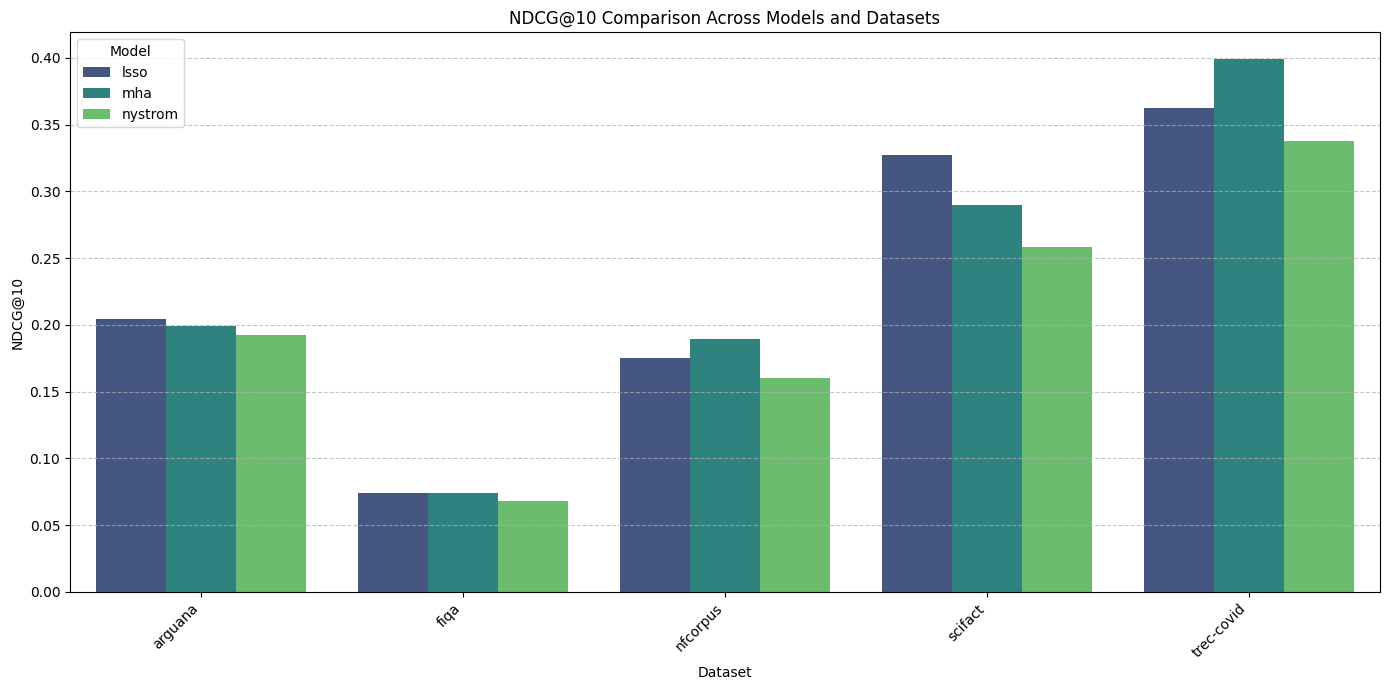

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
df_plot = df.groupby(['model', 'dataset'])['ndcg@10'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x='dataset', y='ndcg@10', hue='model', palette='viridis')
plt.title('NDCG@10 Comparison Across Models and Datasets')
plt.xlabel('Dataset')
plt.ylabel('NDCG@10')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
!tar -czf /content/msmarco_beir_runs_v3_backup.tar.gz -C /content msmarco_beir_runs_v3 || true
!ls -lh /content/msmarco_beir_runs_v3_backup.tar.gz || true

-rw-r--r-- 1 root root 955M Jun  2 10:47 /content/msmarco_beir_runs_v3_backup.tar.gz


In [ ]:
from google.colab import files

files.download('/content/msmarco_beir_runs_v3_backup.tar.gz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import runtime
runtime.unassign()